In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import requests

In [2]:
THAMES_MEASURE = "0006-level-tidal_level-i-15_min-mAOD"


def get_thames(limit=500):
    """Fetch recent Thames tidal readings at Westminster."""
    resp = requests.get(
        f"https://environment.data.gov.uk/flood-monitoring/id/measures/{THAMES_MEASURE}/readings",
        params={"_sorted": "", "_limit": limit},
    )
    resp.raise_for_status()
    items = resp.json().get("items", [])
    df = pd.DataFrame(items)[["dateTime", "value"]].rename(
        columns={"dateTime": "time", "value": "level"}
    )
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df.sort_values("time").reset_index(drop=True)

In [3]:
df = get_thames()

In [4]:
df.reset_index(inplace = True, drop = True)

In [5]:
df

,time,level
0,2026-02-23 22:15:00+00:00,-0.857
1,2026-02-23 22:30:00+00:00,-1.051
2,2026-02-23 22:45:00+00:00,-1.239
3,2026-02-23 23:00:00+00:00,-1.411
4,2026-02-23 23:15:00+00:00,-1.562
...,...,...
495,2026-03-01 02:00:00+00:00,1.111
496,2026-03-01 02:15:00+00:00,0.854
497,2026-03-01 02:30:00+00:00,0.604
498,2026-03-01 02:45:00+00:00,0.363


In [6]:

# --- STEP 1: Prepare dataframe FIRST ---
df['time'] = pd.to_datetime(df['time'])

df = df[df['time'] >= pd.to_datetime('2026-02-01 00:00:00+00:00')]

/tmp/ipykernel_1152401/1599063319.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.asfreq('15T')
/home/cy/miniconda3/envs/cyt/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                              level   No. Observations:                  500
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 50)   Log Likelihood                 877.865
Date:                            Sun, 01 Mar 2026   AIC                          -1745.730
Time:                                    03:30:34   BIC                          -1725.206
Sample:                                02-23-2026   HQIC                         -1737.639
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9881      0.009    115.372      0.000       0.971       1.005
ma.L1          1.7333      0.087   

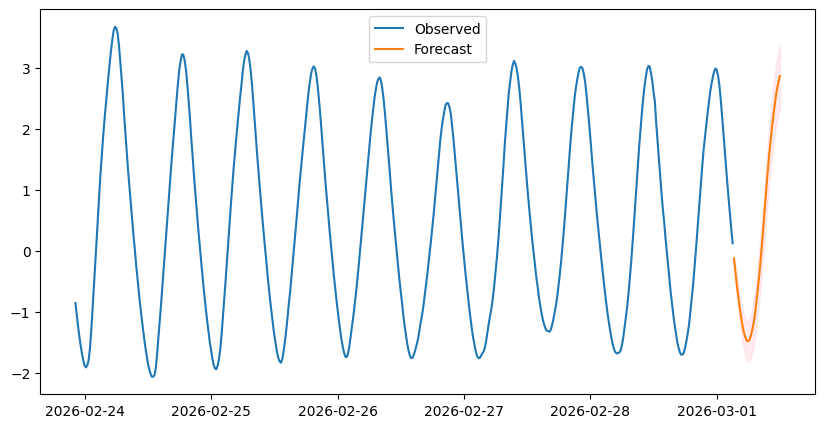

In [7]:


# Remove timezone (statsmodels handles naive better)
df['time'] = df['time'].dt.tz_convert(None)



df = df.set_index('time')
df = df.sort_index()

# Set 15-min frequency explicitly
df = df.asfreq('15T')

# --- STEP 2: Fit SARIMA ---
model = SARIMAX(
    df['level'],
    order=(1,0,1),
    seasonal_order=(1,0,1,50),  # daily seasonality (96 for 15-min data)
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()
print(results.summary())

# --- STEP 3: Calculate steps ---
last_time = df.index[-1]
target_time = pd.Timestamp("2026-03-01 12:00:00")

steps = int((target_time - last_time).total_seconds() / 900)  # 900 sec = 15 min
print("Forecast steps needed:", steps)

# --- STEP 4: Forecast ---
forecast = results.get_forecast(steps=steps)
forecast_ci = forecast.conf_int()

plt.figure(figsize=(10,5))
plt.plot(df['level'], label='Observed')
plt.plot(forecast.predicted_mean, label='Forecast')
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='pink',
    alpha=0.3
)

plt.legend()
plt.show()

In [8]:
# Build sarima_pred_df: merge in-sample fitted values + forecast with observed data

def straddle(value):
    if value < 0.2:
        return 0.2 - value
    elif value > 0.25:
        return value - 0.25
    return 0.0

# In-sample predictions (historical fitted values)
insample_pred = results.get_prediction(start=0).predicted_mean

# Out-of-sample forecast predictions (already computed in prior cell)
oos_pred = forecast.predicted_mean

# Combine into one prediction series
all_pred = pd.concat([insample_pred, oos_pred])

# Merge predictions with observed levels
sarima_pred_df = pd.DataFrame({'pred_mean': all_pred})
sarima_pred_df['level'] = df['level'].reindex(sarima_pred_df.index)

# Slice for target window: 28 Feb 12:00 -> 1 Mar 12:00
start_28_12 = pd.Timestamp("2026-02-28 12:00:00")
end_01_12 = pd.Timestamp("2026-03-01 12:00:00")

sarima_28_01 = sarima_pred_df.loc[start_28_12:end_01_12].copy()

# Compute absolute step changes of the predicted mean and apply straddle()
sarima_28_01['level_diff'] = sarima_28_01['pred_mean'].diff().abs()
sarima_28_01['price'] = sarima_28_01['level_diff'].apply(straddle)

# Quick checks
print("Rows:", len(sarima_28_01))
print("sum(price):", sarima_28_01['price'].sum())
sarima_28_01[['pred_mean', 'level', 'level_diff', 'price']]

Rows: 97
sum(price): 5.8493476886753015


,pred_mean,level,level_diff,price
2026-02-28 12:00:00,2.618515,2.605,NaN,0.000000
2026-02-28 12:15:00,2.364236,2.452,0.254279,0.004279
2026-02-28 12:30:00,2.239938,2.100,0.124297,0.075703
2026-02-28 12:45:00,1.757591,1.809,0.482347,0.232347
2026-02-28 13:00:00,1.597392,1.510,0.160200,0.039800
...,...,...,...,...
2026-03-01 11:00:00,2.392539,NaN,0.170272,0.029728
2026-03-01 11:15:00,2.564424,NaN,0.171886,0.028114
2026-03-01 11:30:00,2.688555,NaN,0.124130,0.075870
2026-03-01 11:45:00,2.793868,NaN,0.105314,0.094686


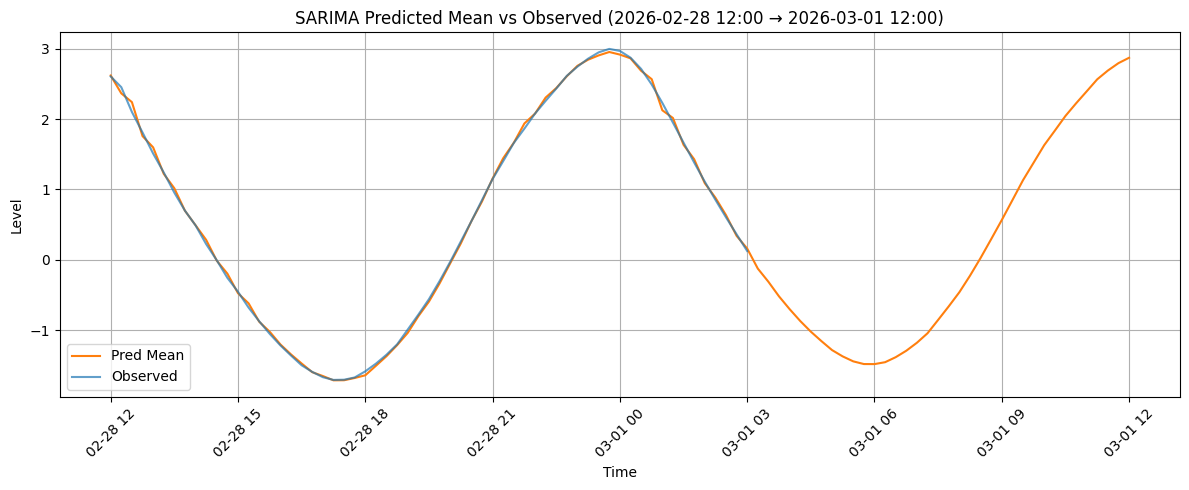

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(sarima_28_01.index, sarima_28_01['pred_mean'], label='Pred Mean', color='C1')
plt.plot(sarima_28_01.index, sarima_28_01['level'], label='Observed', color='C0', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Level')
plt.title('SARIMA Predicted Mean vs Observed (2026-02-28 12:00 → 2026-03-01 12:00)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()